In [2]:
# 1. Importer les bibliothèques

import pandas as pd
import numpy as np
import os

In [3]:
# 2. Charger le fichier créé dans 2_feature_extraction

df = pd.read_csv("../dataset/data_with_features.csv")

df.head()

,user_id,screen_name,followers_count,friends_count,statuses_count,verified,default_profile,default_profile_image,favourites_count,listed_count,...,favorite_count,reply_count,quote_count,lang,hashtags_count,urls_count,mentions_count,tweet_length,is_retweet,is_quote
0,39084553,JojoHtown,556,826,32153,False,True,False,17414,24,...,0,0,0,en,2,0,1,140,1,0
1,1564678657,tricoloraphael,918,686,28445,False,True,False,15412,5,...,0,0,0,pt,0,1,0,51,0,1
2,967244973824339968,tokenbrotha,34,44,4219,False,False,False,2131,0,...,0,0,0,en,0,1,1,46,1,1
3,4872447178,irashediat,2805,3189,5162,False,True,False,144,5,...,0,0,0,ar,2,0,1,140,1,0
4,35628099,aminelion,48,407,487,False,False,False,1124,1,...,0,0,0,en,2,0,2,140,1,0


In [4]:
# 3. Vérifier la taille et les types de données

print("Dimensions :", df.shape)
df.info()

Dimensions : (4569999, 21)
<class 'pandas.DataFrame'>
RangeIndex: 4569999 entries, 0 to 4569998
Data columns (total 21 columns):
 #   Column                 Dtype
---  ------                 -----
 0   user_id                int64
 1   screen_name            str  
 2   followers_count        int64
 3   friends_count          int64
 4   statuses_count         int64
 5   verified               bool 
 6   default_profile        bool 
 7   default_profile_image  bool 
 8   favourites_count       int64
 9   listed_count           int64
 10  retweet_count          int64
 11  favorite_count         int64
 12  reply_count            int64
 13  quote_count            int64
 14  lang                   str  
 15  hashtags_count         int64
 16  urls_count             int64
 17  mentions_count         int64
 18  tweet_length           int64
 19  is_retweet             int64
 20  is_quote               int64
dtypes: bool(3), int64(16), str(2)
memory usage: 640.7 MB


In [5]:
# 4. Agréger les données par utilisateur

# On regroupe les tweets par user_id.
# L'objectif est d'obtenir une ligne par profil utilisateur.

user_df = df.groupby("user_id").agg({
    "screen_name": "first",

    # Variables utilisateur
    "followers_count": "mean",
    "friends_count": "mean",
    "statuses_count": "mean",
    "favourites_count": "mean",
    "listed_count": "mean",

    # Variables booléennes
    "verified": "max",
    "default_profile": "max",
    "default_profile_image": "max",

    # Variables tweet
    "retweet_count": "mean",
    "favorite_count": "mean",
    "reply_count": "mean",
    "quote_count": "mean",

    # Variables contenu
    "hashtags_count": "mean",
    "urls_count": "mean",
    "mentions_count": "mean",
    "tweet_length": "mean",

    # Type de tweet
    "is_retweet": "mean",
    "is_quote": "mean",

    # Langue dominante
    "lang": lambda x: x.mode()[0] if len(x.mode()) > 0 else "unknown"
}).reset_index()

user_df.head()

,user_id,screen_name,followers_count,friends_count,statuses_count,favourites_count,listed_count,verified,default_profile,default_profile_image,...,favorite_count,reply_count,quote_count,hashtags_count,urls_count,mentions_count,tweet_length,is_retweet,is_quote,lang
0,418,dens,87897.333333,2487.833333,66634.166667,13506.0,4535.5,True,False,False,...,0.0,0.0,0.0,1.0,0.5,0.666667,113.333333,0.5,0.5,en
1,730,crutis,621.000000,191.000000,12159.000000,3164.0,20.0,False,False,False,...,0.0,0.0,0.0,0.0,0.0,1.000000,139.000000,1.0,1.0,en
2,761,RodBegbie,4562.000000,483.000000,29724.000000,46254.0,188.0,False,False,False,...,0.0,0.0,0.0,0.0,1.0,0.000000,31.000000,0.0,1.0,en
3,885,Ross,21491.000000,1099.000000,13879.000000,6091.0,1883.0,True,False,False,...,0.0,0.0,0.0,1.0,0.0,0.000000,88.000000,0.0,0.0,en
4,922,Holger,4399.000000,934.000000,11717.000000,12046.0,268.0,False,False,False,...,0.0,0.0,0.0,3.0,0.0,1.000000,140.000000,0.0,0.0,en


In [6]:
# 5. Ajouter le nombre de tweets par utilisateur

# Cette variable mesure l'activité de chaque utilisateur dans le dataset.

n_tweets = df.groupby("user_id").size().reset_index(name="n_tweets")

user_df = user_df.merge(n_tweets, on="user_id", how="left")

user_df.head()

,user_id,screen_name,followers_count,friends_count,statuses_count,favourites_count,listed_count,verified,default_profile,default_profile_image,...,reply_count,quote_count,hashtags_count,urls_count,mentions_count,tweet_length,is_retweet,is_quote,lang,n_tweets
0,418,dens,87897.333333,2487.833333,66634.166667,13506.0,4535.5,True,False,False,...,0.0,0.0,1.0,0.5,0.666667,113.333333,0.5,0.5,en,6
1,730,crutis,621.000000,191.000000,12159.000000,3164.0,20.0,False,False,False,...,0.0,0.0,0.0,0.0,1.000000,139.000000,1.0,1.0,en,1
2,761,RodBegbie,4562.000000,483.000000,29724.000000,46254.0,188.0,False,False,False,...,0.0,0.0,0.0,1.0,0.000000,31.000000,0.0,1.0,en,1
3,885,Ross,21491.000000,1099.000000,13879.000000,6091.0,1883.0,True,False,False,...,0.0,0.0,1.0,0.0,0.000000,88.000000,0.0,0.0,en,1
4,922,Holger,4399.000000,934.000000,11717.000000,12046.0,268.0,False,False,False,...,0.0,0.0,3.0,0.0,1.000000,140.000000,0.0,0.0,en,1


In [7]:
# 6. Créer des indicateurs supplémentaires

# Ratio followers / friends
user_df["followers_friends_ratio"] = (
    user_df["followers_count"] / (user_df["friends_count"] + 1)
)

# Ratio d'activité du compte
user_df["activity_ratio"] = (
    user_df["statuses_count"] / (user_df["followers_count"] + 1)
)

# Score simple de visibilité
user_df["visibility_score"] = (
    user_df["followers_count"] + user_df["listed_count"] * 10
)

user_df.head()

,user_id,screen_name,followers_count,friends_count,statuses_count,favourites_count,listed_count,verified,default_profile,default_profile_image,...,urls_count,mentions_count,tweet_length,is_retweet,is_quote,lang,n_tweets,followers_friends_ratio,activity_ratio,visibility_score
0,418,dens,87897.333333,2487.833333,66634.166667,13506.0,4535.5,True,False,False,...,0.5,0.666667,113.333333,0.5,0.5,en,6,35.316681,0.758082,133252.333333
1,730,crutis,621.000000,191.000000,12159.000000,3164.0,20.0,False,False,False,...,0.0,1.000000,139.000000,1.0,1.0,en,1,3.234375,19.548232,821.000000
2,761,RodBegbie,4562.000000,483.000000,29724.000000,46254.0,188.0,False,False,False,...,1.0,0.000000,31.000000,0.0,1.0,en,1,9.425620,6.514135,6442.000000
3,885,Ross,21491.000000,1099.000000,13879.000000,6091.0,1883.0,True,False,False,...,0.0,0.000000,88.000000,0.0,0.0,en,1,19.537273,0.645775,40321.000000
4,922,Holger,4399.000000,934.000000,11717.000000,12046.0,268.0,False,False,False,...,0.0,1.000000,140.000000,0.0,0.0,en,1,4.704813,2.662955,7079.000000


In [8]:
# 7. Convertir les booléens en 0/1

bool_columns = [
    "verified",
    "default_profile",
    "default_profile_image"
]

for col in bool_columns:
    user_df[col] = user_df[col].astype(int)

user_df.head()

,user_id,screen_name,followers_count,friends_count,statuses_count,favourites_count,listed_count,verified,default_profile,default_profile_image,...,urls_count,mentions_count,tweet_length,is_retweet,is_quote,lang,n_tweets,followers_friends_ratio,activity_ratio,visibility_score
0,418,dens,87897.333333,2487.833333,66634.166667,13506.0,4535.5,1,0,0,...,0.5,0.666667,113.333333,0.5,0.5,en,6,35.316681,0.758082,133252.333333
1,730,crutis,621.000000,191.000000,12159.000000,3164.0,20.0,0,0,0,...,0.0,1.000000,139.000000,1.0,1.0,en,1,3.234375,19.548232,821.000000
2,761,RodBegbie,4562.000000,483.000000,29724.000000,46254.0,188.0,0,0,0,...,1.0,0.000000,31.000000,0.0,1.0,en,1,9.425620,6.514135,6442.000000
3,885,Ross,21491.000000,1099.000000,13879.000000,6091.0,1883.0,1,0,0,...,0.0,0.000000,88.000000,0.0,0.0,en,1,19.537273,0.645775,40321.000000
4,922,Holger,4399.000000,934.000000,11717.000000,12046.0,268.0,0,0,0,...,0.0,1.000000,140.000000,0.0,0.0,en,1,4.704813,2.662955,7079.000000


In [9]:
# 8. Nettoyer les valeurs manquantes

user_df = user_df.fillna(0)

user_df.isnull().sum()

user_id                    0
screen_name                0
followers_count            0
friends_count              0
statuses_count             0
favourites_count           0
listed_count               0
verified                   0
default_profile            0
default_profile_image      0
retweet_count              0
favorite_count             0
reply_count                0
quote_count                0
hashtags_count             0
urls_count                 0
mentions_count             0
tweet_length               0
is_retweet                 0
is_quote                   0
lang                       0
n_tweets                   0
followers_friends_ratio    0
activity_ratio             0
visibility_score           0
dtype: int64

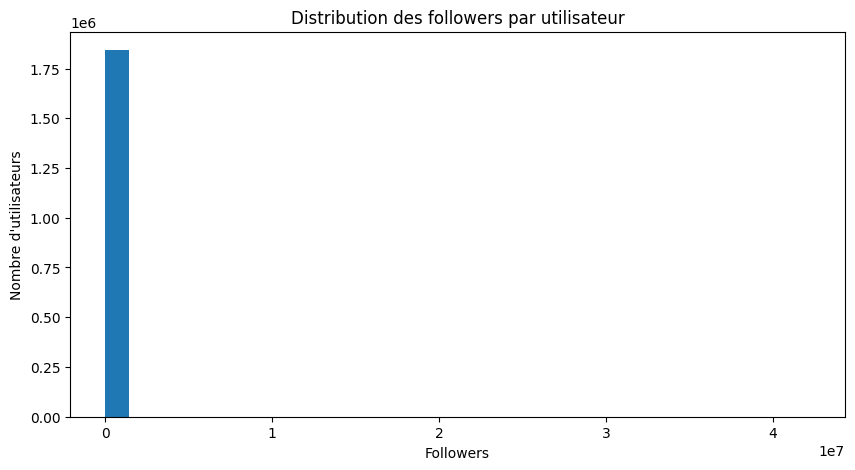

In [12]:
# Visualiser la distribution des followers

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(user_df["followers_count"], bins=30)

plt.title("Distribution des followers par utilisateur")
plt.xlabel("Followers")
plt.ylabel("Nombre d'utilisateurs")

plt.show()

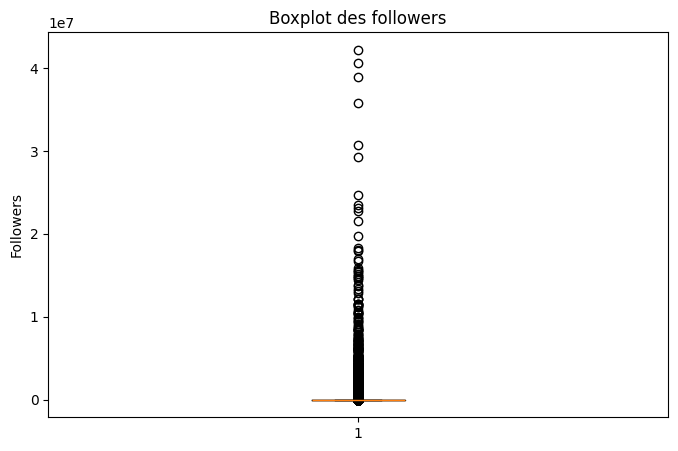

In [13]:
# Visualiser les valeurs extrêmes des followers

plt.figure(figsize=(8, 5))

plt.boxplot(user_df["followers_count"])

plt.title("Boxplot des followers")
plt.ylabel("Followers")

plt.show()

In [10]:
# 9. Vérifier les statistiques finales

print("Dimensions du dataset utilisateur :", user_df.shape)

user_df.describe()

Dimensions du dataset utilisateur : (1843439, 25)


,user_id,followers_count,friends_count,statuses_count,favourites_count,listed_count,verified,default_profile,default_profile_image,retweet_count,...,hashtags_count,urls_count,mentions_count,tweet_length,is_retweet,is_quote,n_tweets,followers_friends_ratio,activity_ratio,visibility_score
count,1.843439e+06,1.843439e+06,1.843439e+06,1.843439e+06,1.843439e+06,1.843439e+06,1.843439e+06,1.843439e+06,1843439.0,1843439.0,...,1.843439e+06,1.843439e+06,1.843439e+06,1.843439e+06,1.843439e+06,1.843439e+06,1.843439e+06,1.843439e+06,1.843439e+06,1.843439e+06
mean,2.276477e+17,3.601228e+03,8.702604e+02,1.767618e+04,8.753502e+03,2.439481e+01,9.809383e-03,5.143197e-01,0.0,0.0,...,1.488079e+00,2.785999e-01,9.072910e-01,1.079493e+02,7.165108e-01,1.955831e-01,2.479062e+00,6.973013e+01,4.170335e+01,3.845176e+03
std,3.886710e+17,1.185477e+05,4.887334e+03,4.048294e+04,2.203403e+04,3.975126e+02,9.855539e-02,4.997950e-01,0.0,0.0,...,1.415802e+00,4.224853e-01,6.843611e-01,3.147597e+01,4.264903e-01,3.689984e-01,9.279491e+00,1.116210e+04,4.770392e+02,1.214129e+05
min,4.180000e+02,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,...,0.000000e+00,0.000000e+00,0.000000e+00,9.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,5.887891e-06,0.000000e+00
25%,3.033891e+08,1.030000e+02,1.680000e+02,1.104667e+03,4.430000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,...,5.000000e-01,0.000000e+00,5.294118e-01,8.800000e+01,3.157895e-01,0.000000e+00,1.000000e+00,3.618421e-01,5.516045e+00,1.170000e+02
50%,1.460774e+09,2.980000e+02,3.570000e+02,5.204000e+03,2.164000e+03,2.000000e+00,0.000000e+00,1.000000e+00,0.0,0.0,...,1.000000e+00,0.000000e+00,1.000000e+00,1.130000e+02,1.000000e+00,0.000000e+00,1.000000e+00,8.084772e-01,1.640223e+01,3.400000e+02
75%,7.125350e+17,7.530000e+02,7.580000e+02,1.788500e+04,7.921750e+03,8.571429e+00,0.000000e+00,1.000000e+00,0.0,0.0,...,2.000000e+00,5.000000e-01,1.000000e+00,1.395000e+02,1.000000e+00,1.333333e-01,2.000000e+00,1.393298e+00,3.978160e+01,8.730000e+02
max,1.008393e+18,4.220008e+07,1.569366e+06,8.902826e+06,1.718515e+06,1.953537e+05,1.000000e+00,1.000000e+00,0.0,0.0,...,2.500000e+01,5.000000e+00,1.200000e+01,4.160000e+02,1.000000e+00,1.000000e+00,7.143000e+03,7.774430e+06,2.494400e+05,4.415362e+07


In [11]:
# 10. Sauvegarder le dataset final utilisateur

output_path = "../dataset/user_twitter_data.csv"

user_df.to_csv(output_path, index=False, encoding="utf-8")

print("Dataset utilisateur sauvegardé :", output_path)

Dataset utilisateur sauvegardé : ../dataset/user_twitter_data.csv
